========== BÁO CÁO ĐÁNH GIÁ MÔ HÌNH (CLASSIFICATION REPORT) ==========
              precision    recall  f1-score   support

    Tích cực       1.00      0.40      0.57        15
   Trung lập       0.81      1.00      0.90        43
    Tiêu cực       1.00      0.50      0.67         2

    accuracy                           0.83        60
   macro avg       0.94      0.63      0.71        60
weighted avg       0.86      0.83      0.81        60


Độ chính xác tổng thể (Accuracy): 83.33%

Đã lưu biểu đồ thành file 'confusion_matrix.png'.


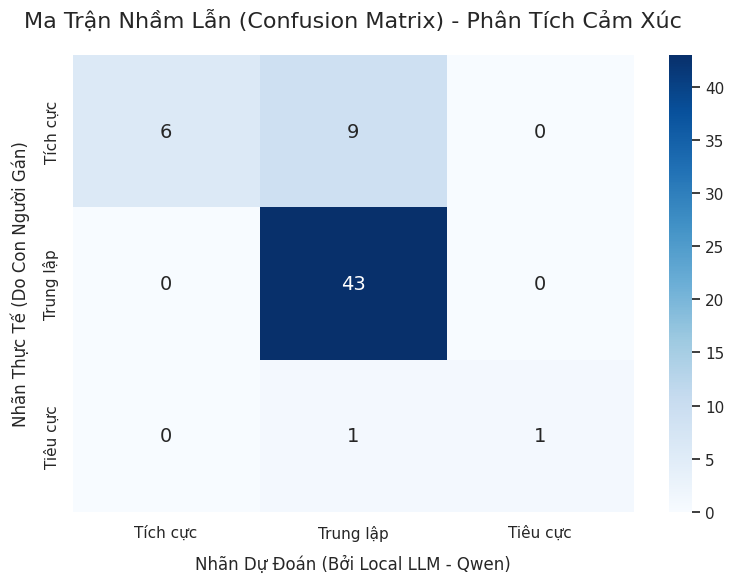

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ==========================================
# BƯỚC 1: CHUẨN BỊ DỮ LIỆU ĐÁNH GIÁ (50 MẪU)
# ==========================================

# Nhãn hợp lệ: "Tích cực", "Tiêu cực", "Trung lập"
y_human = ["Trung lập", "Trung lập", "Trung lập", "Tích cực", "Tích cực", "Tiêu cực",
"Trung lập", "Tích cực", "Tích cực", "Tiêu cực", "Tích cực", "Trung lập",
"Trung lập", "Trung lập", "Tích cực", "Trung lập", "Trung lập", "Trung lập",
"Trung lập", "Trung lập", "Tích cực", "Trung lập", "Tích cực", "Trung lập",
"Tích cực", "Tích cực", "Trung lập", "Trung lập", "Trung lập", "Trung lập",
"Trung lập", "Trung lập", "Trung lập", "Trung lập", "Trung lập", "Trung lập",
"Trung lập", "Tích cực", "Trung lập", "Trung lập", "Trung lập", "Trung lập",
"Trung lập", "Trung lập", "Trung lập", "Trung lập", "Trung lập", "Trung lập",
"Trung lập", "Tích cực", "Trung lập", "Trung lập", "Tích cực", "Tích cực",
"Trung lập", "Trung lập", "Trung lập", "Trung lập", "Trung lập", "Tích cực"
]



y_llm = ["Trung lập", "Trung lập", "Trung lập", "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Tích cực"
, "Tích cực"
, "Tiêu cực"
, "Tích cực"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Tích cực"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Tích cực"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Trung lập"
, "Tích cực"
]

labels = ["Tích cực", "Trung lập", "Tiêu cực"]

# ==========================================
# BƯỚC 2: TÍNH TOÁN CÁC CHỈ SỐ NLP CƠ BẢN
# ==========================================
print("========== BÁO CÁO ĐÁNH GIÁ MÔ HÌNH (CLASSIFICATION REPORT) ==========")
# Hàm này tự động tính Precision, Recall, F1-Score cho từng nhãn
report = classification_report(y_human, y_llm, labels=labels, target_names=labels)
print(report)

accuracy = accuracy_score(y_human, y_llm)
print(f"\nĐộ chính xác tổng thể (Accuracy): {accuracy * 100:.2f}%\n")

# ==========================================
# BƯỚC 3: VẼ MA TRẬN NHẦM LẪN (CONFUSION MATRIX)
# ==========================================
cm = confusion_matrix(y_human, y_llm, labels=labels)

# Cấu hình biểu đồ
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid", font="sans-serif") # Set font mặc định

# Vẽ heatmap
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                 xticklabels=labels, yticklabels=labels,
                 annot_kws={"size": 14})

# Thiết lập tiêu đề và nhãn trục
plt.title('Ma Trận Nhầm Lẫn (Confusion Matrix) - Phân Tích Cảm Xúc', fontsize=16, pad=20)
plt.xlabel('Nhãn Dự Đoán (Bởi Local LLM - Qwen)', fontsize=12, labelpad=10)
plt.ylabel('Nhãn Thực Tế (Do Con Người Gán)', fontsize=12, labelpad=10)

# Lưu hình ảnh để dán vào báo cáo Word
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
print("Đã lưu biểu đồ thành file 'confusion_matrix.png'.")

# Hiển thị biểu đồ
plt.show()